# Interactive Dipole Placement Pipeline

This notebook demonstrates the full modular pipeline for magnetic dipole reconstruction:

1. Load or create magnetic field data as a Dataset
2. Visualize the field using Show
3. Interactive dipole placement using DipoleLocator
4. Visualize dipole locations
5. Reconstruct the field using Propagator


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from magrec.misc.data import Dataset
from magrec.prop import Pipeline, Show, DipoleLocator, Dipoles, Propagator, Projector


## 1. Create Synthetic Magnetic Field Data

We'll create a synthetic magnetic field from a few point sources.


In [6]:
# Create a grid
x = np.linspace(-10, 10, 300)
y = np.linspace(-10, 10, 300)
z = np.array([5.0])  # Height above dipole,

# Create Dataset
ds = Dataset()
ds.dimensions = (len(x), len(y), len(z))
ds.origin = (x[0], y[0], z[0])
ds.spacing = (x[1] - x[0], y[1] - y[0], 1.0)

# Generate synthetic field from 3 dipoles
true_dipoles = np.array([
    [-3, -3, 0],
    [3, -3, 0],
    [0, 3, 0]
])

moments = np.array([
    [0, 0, 1.0],
    [0, 0, 1.5],
    [0, 0, -1.0]
])

# Compute field at each point
points = ds.points
B = np.zeros((len(points), 3))

mu_0 = 4 * np.pi * 1e-7  # Permeability
for dipole_pos, moment in zip(true_dipoles, moments):
    r = points - dipole_pos
    r_norm = np.linalg.norm(r, axis=1, keepdims=True)
    r_hat = r / (r_norm + 1e-10)
    
    # Dipole field: B = (mu_0 / 4pi) * (3(m·r)r/r^5 - m/r^3)
    m_dot_r = np.sum(moment * r_hat, axis=1, keepdims=True)
    B += (mu_0 / (4 * np.pi)) * (
        3 * m_dot_r * r_hat / (r_norm**3 + 1e-10) - 
        moment / (r_norm**3 + 1e-10)
    )

# Add some noise
# B += np.random.normal(0, 1e-10, B.shape)

# Store in dataset
ds.point_data['B'] = B

print(f"Dataset shape: {ds.dimensions}")
print(f"Field shape: {B.shape}")
print(f"True dipoles at: {true_dipoles}")


Dataset shape: (300, 300, 1)
Field shape: (90000, 3)
True dipoles at: [[-3 -3  0]
 [ 3 -3  0]
 [ 0  3  0]]


## 2. Visualize the Magnetic Field

First, let's visualize the z-component of the magnetic field.


In [9]:
B.shape

(2500, 3)

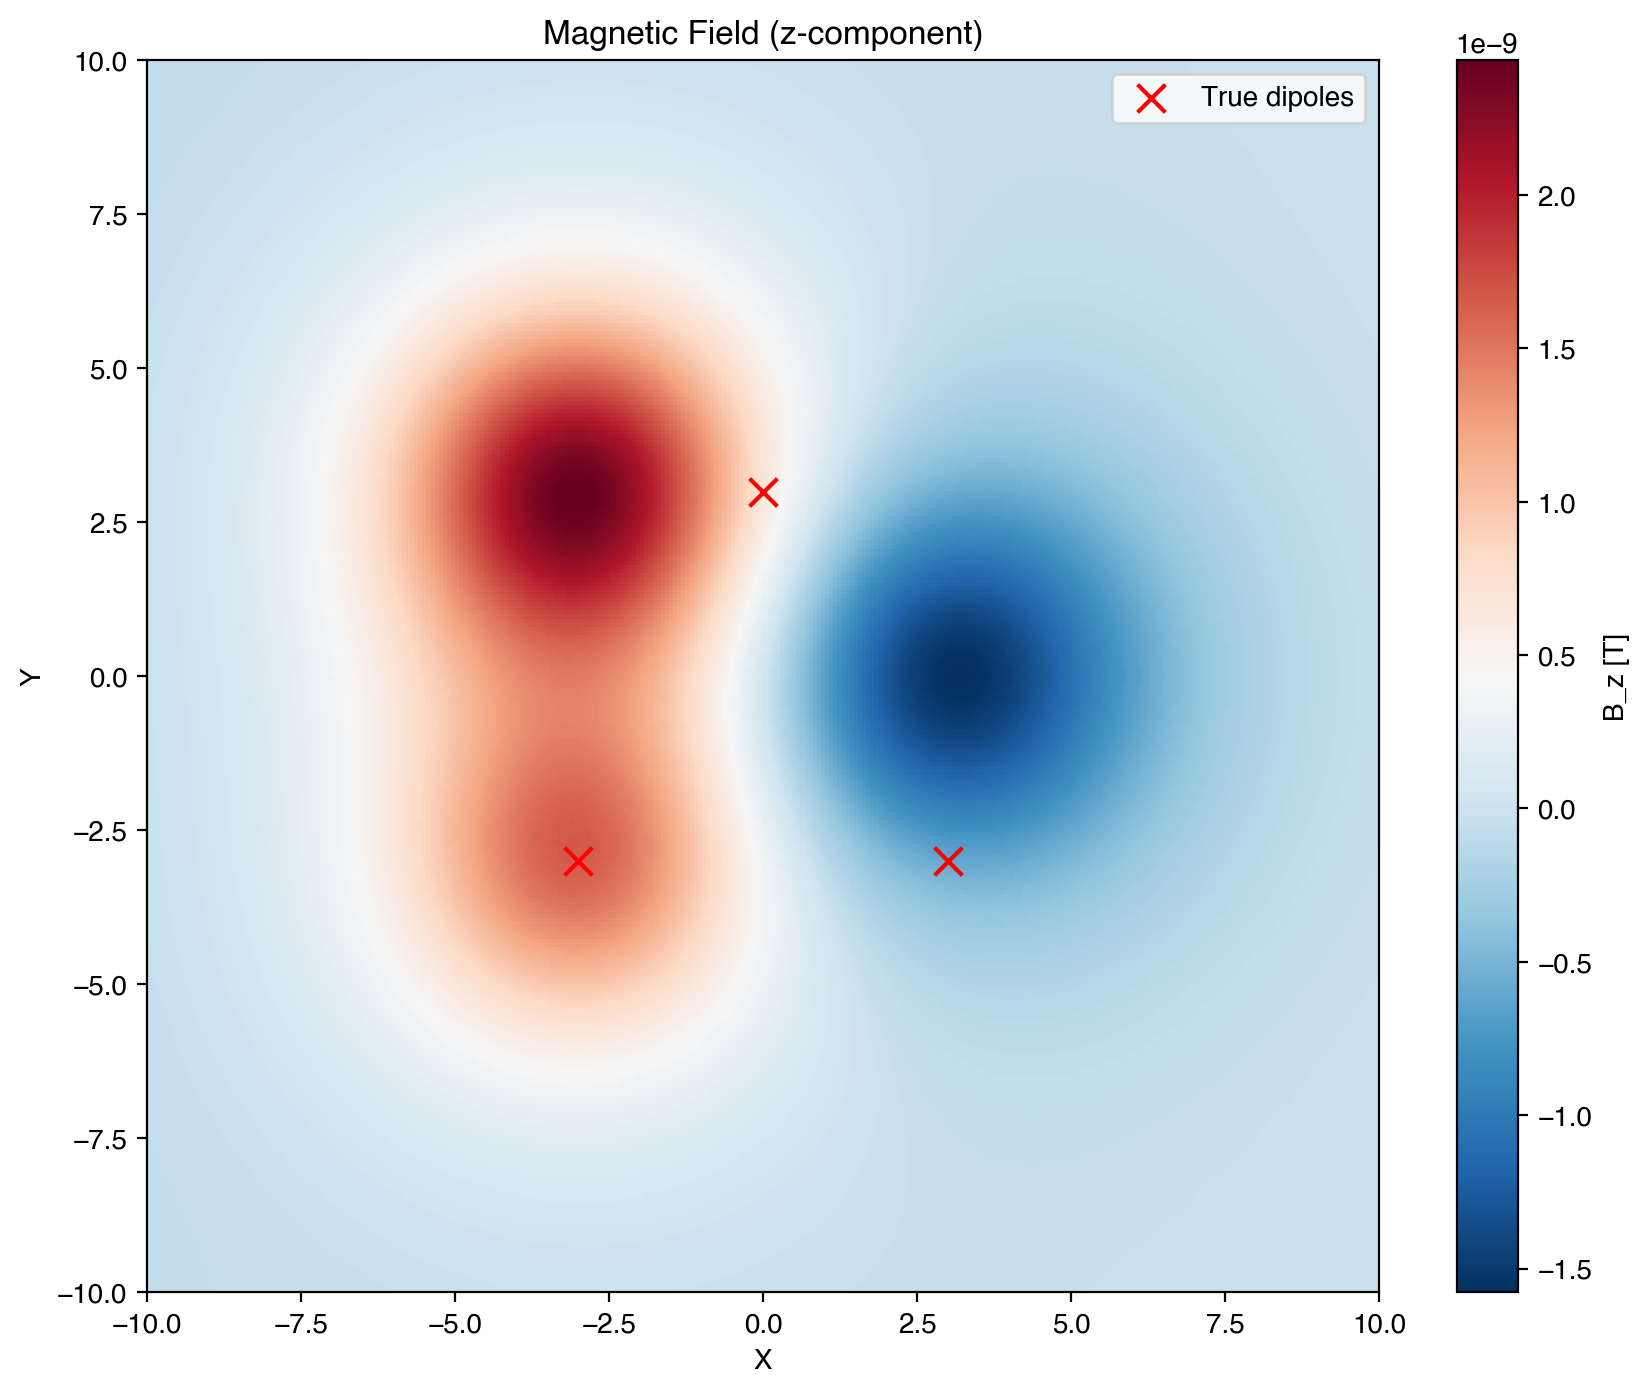

In [7]:
# Simple matplotlib visualization
B_z = B[:, 2].reshape(ds.dimensions[:2])

plt.figure(figsize=(10, 8))
plt.imshow(B_z.T, origin='lower', extent=[x[0], x[-1], y[0], y[-1]], cmap='RdBu_r')
plt.colorbar(label='B_z [T]')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Magnetic Field (z-component)')
plt.scatter(true_dipoles[:, 0], true_dipoles[:, 1], c='red', s=100, marker='x', label='True dipoles')
plt.legend()
plt.show()


## 3. Interactive Dipole Placement

Use DipoleLocator to place dipoles. Set `interactive=False` for uniform placement, or `interactive=True` to draw a polygon.


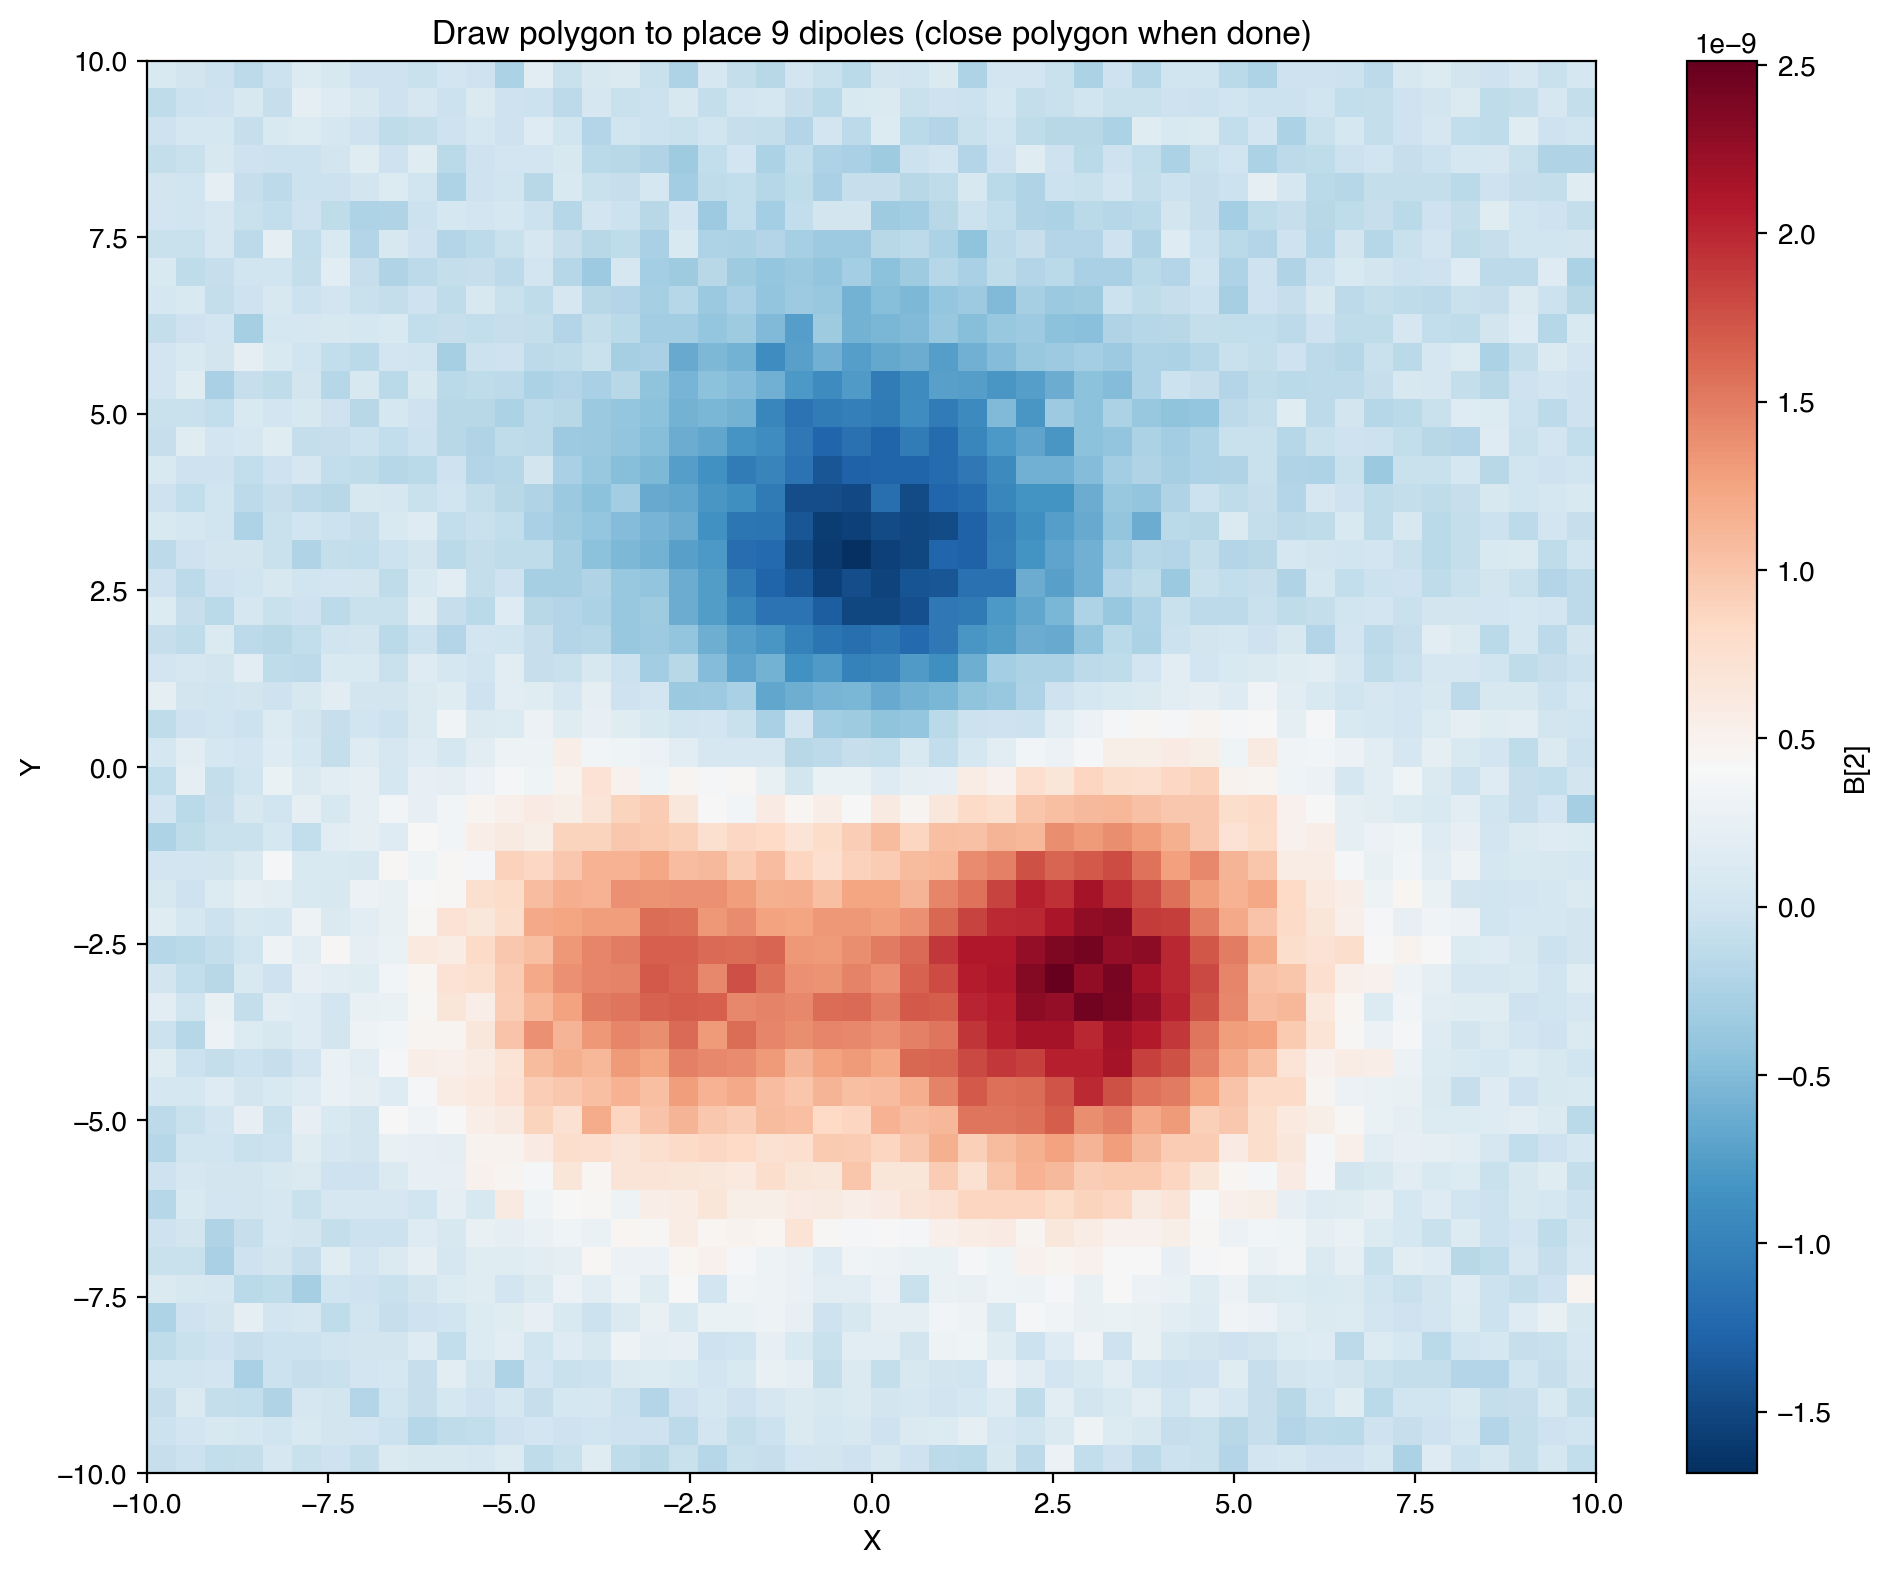

No valid polygon drawn, using uniform placement
Placed 9 dipoles
Dipole locations:
[[-1.0000000e+01 -1.0000000e+01  0.0000000e+00]
 [-1.0658141e-14 -1.0000000e+01  0.0000000e+00]
 [ 1.0000000e+01 -1.0000000e+01  0.0000000e+00]
 [-1.0000000e+01 -1.0658141e-14  0.0000000e+00]
 [-1.0658141e-14 -1.0658141e-14  0.0000000e+00]
 [ 1.0000000e+01 -1.0658141e-14  0.0000000e+00]
 [-1.0000000e+01  1.0000000e+01  0.0000000e+00]
 [-1.0658141e-14  1.0000000e+01  0.0000000e+00]
 [ 1.0000000e+01  1.0000000e+01  0.0000000e+00]]


In [8]:
# Create pipeline with uniform placement
pipe = Pipeline([
    ds,  # Dataset as first step
    DipoleLocator(n_dipoles=9, interactive=True, out='dipole_locs')
])

result = pipe.run()

# Get dipole locations
dipole_locs = result['dipole_locs']
print(f"Placed {len(dipole_locs)} dipoles")
print(f"Dipole locations:\n{dipole_locs}")


## 4. Visualize Dipole Locations

Show the field with overlaid dipole locations.


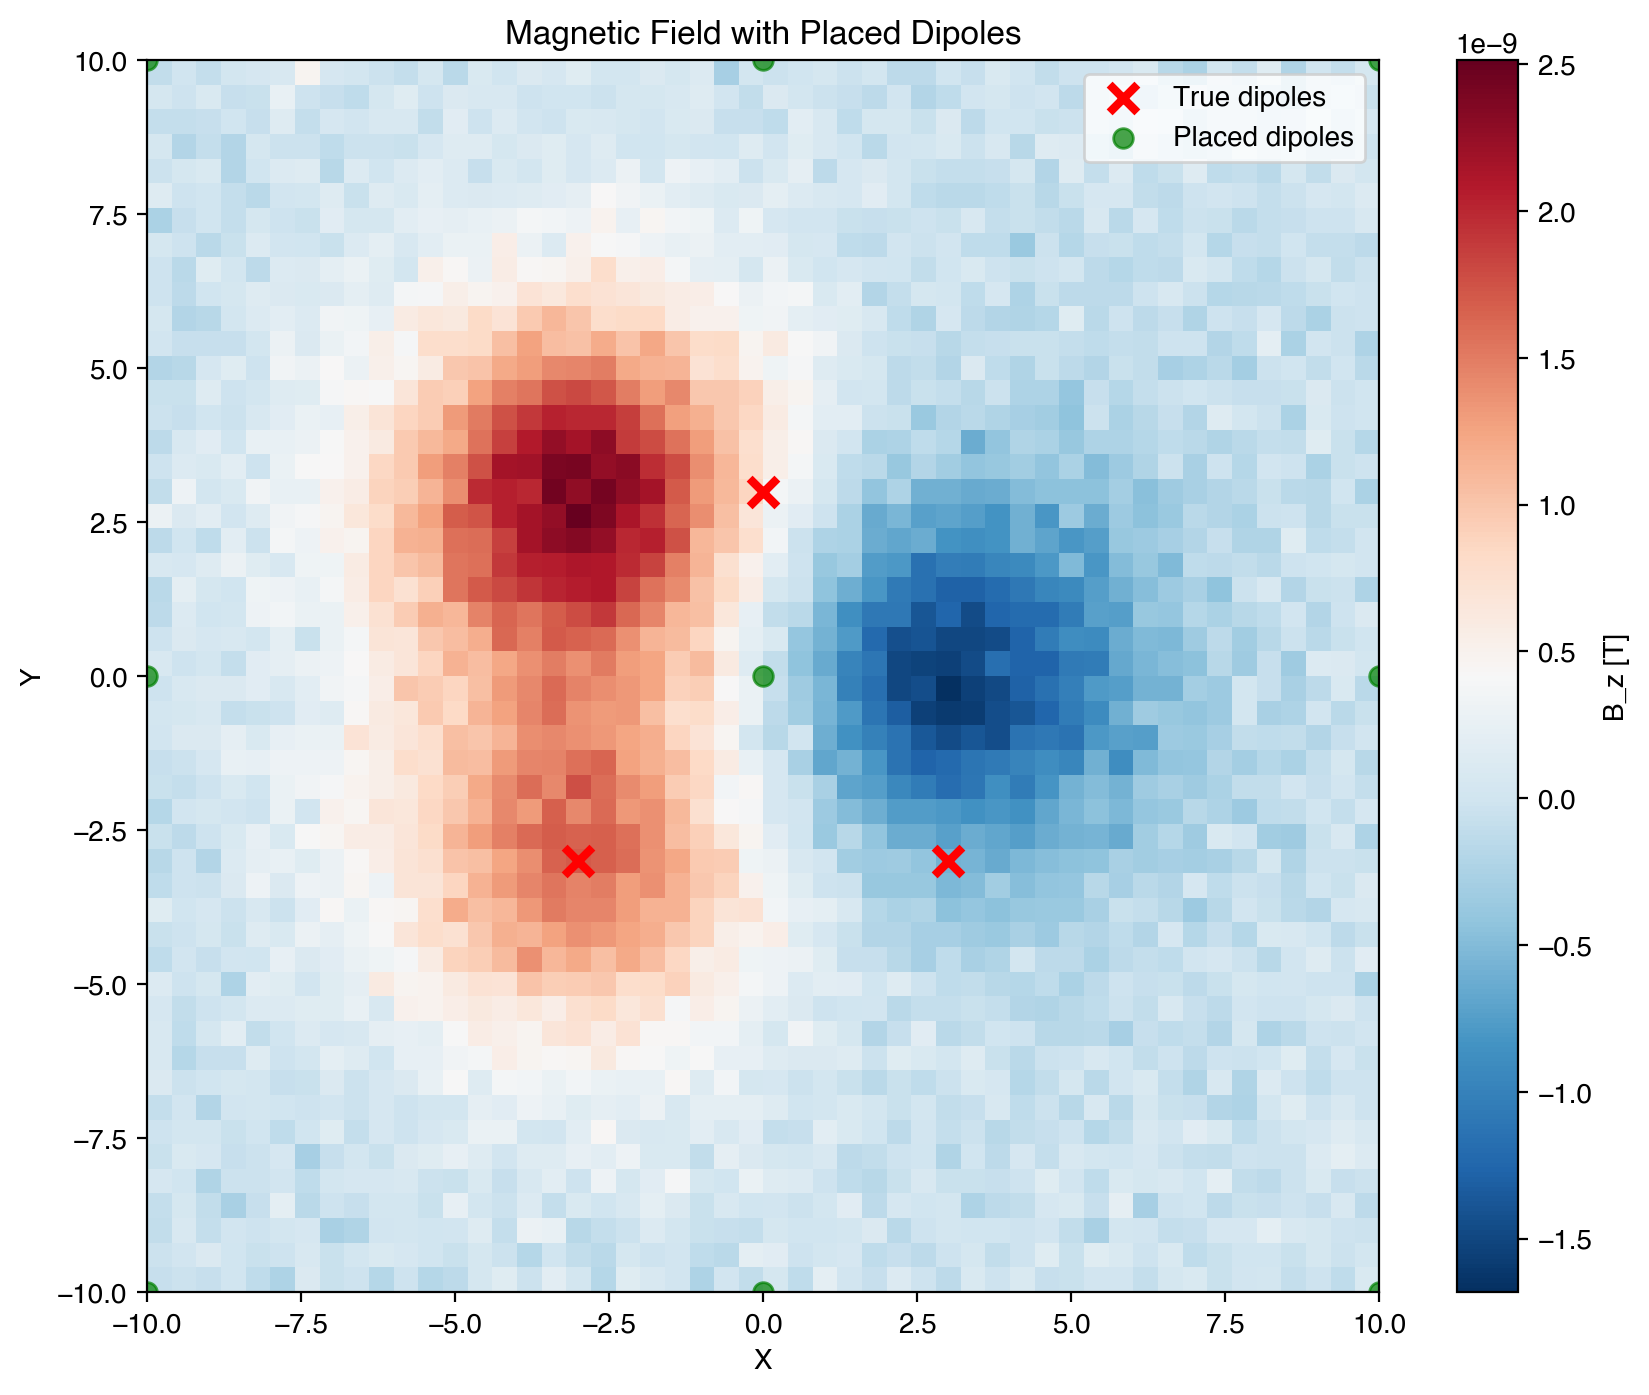

In [7]:
# Visualize field with dipoles
plt.figure(figsize=(10, 8))
plt.imshow(B_z.T, origin='lower', extent=[x[0], x[-1], y[0], y[-1]], cmap='RdBu_r')
plt.colorbar(label='B_z [T]')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Magnetic Field with Placed Dipoles')

# Plot true dipoles
plt.scatter(true_dipoles[:, 0], true_dipoles[:, 1], 
           c='red', s=100, marker='x', label='True dipoles', linewidths=3)

# Plot placed dipoles
plt.scatter(dipole_locs[:, 0], dipole_locs[:, 1], 
           c='green', s=50, marker='o', label='Placed dipoles', alpha=0.7)

plt.legend()
plt.show()


## Summary

This notebook demonstrated:
- Creating synthetic magnetic field data as a Dataset
- Using DipoleLocator for uniform dipole placement  
- Visualizing results with matplotlib
- Building modular pipelines with the new Pipeline architecture

Key features:
- **Data-oriented**: Immutable dictionaries flow through the pipeline
- **Modular**: Each step is independent and composable
- **Interactive**: DipoleLocator allows drawing polygons to place dipoles (set `interactive=True`)
- **Flexible**: Any Python object can be a step (Dataset, integers, functions)
- **Traceable**: Pipeline logs all artifacts and their creation steps

To use interactive mode, set `interactive=True` in DipoleLocator and draw a polygon around the desired region.
